# Trial32 event catalogs

Build earthquake-style snap, subavalanche, and avalanche catalogs directly from the modular `crumpling` pipeline. Snap magnitude is zero (unit event); cascade and avalanche magnitude is `log10(n_swaps)`.

In [10]:
import pathlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import signal


def find_repo_root() -> pathlib.Path:
    here = pathlib.Path.cwd().resolve()
    for base in (here, *here.parents):
        if (base / "pyproject.toml").is_file() and (base / "crumpling").is_dir():
            return base
    raise FileNotFoundError(f"Could not locate the repository above {here}")


ROOT = find_repo_root()
sys.path.insert(0, str(ROOT))

import crumpling.catalogs
import crumpling.config
import crumpling.pipeline

DATA = ROOT / "data/raw/trial32/N40K-compress-LJ10-T0.001-F0.61-damp4.0_stage1_trial32_dt10-dr400__swaps.txt"
CONFIG = ROOT / "configs/trial32/swapstat.params.ini"
plt.style.use("seaborn-v0_8-whitegrid")


In [2]:
settings = crumpling.config.load_config(CONFIG)
result = crumpling.pipeline.analyze_file(DATA, settings)

snaps = crumpling.catalogs.snaps(result)
subav = crumpling.catalogs.subavalanches(result)
av = crumpling.catalogs.avalanches(result)

summary = pd.DataFrame(
    {
        "catalog": ["snaps", "subavalanches", "avalanches"],
        "events": [len(snaps), len(subav), len(av)],
        "start_time": [frame["time"].min() for frame in (snaps, subav, av)],
        "end_time": [frame["time"].max() for frame in (snaps, subav, av)],
        "median_dt": [frame["dt"].median() for frame in (snaps, subav, av)],
        "max_magnitude": [frame["magnitude"].max() for frame in (snaps, subav, av)],
    }
).set_index("catalog")
summary


,events,start_time,end_time,median_dt,max_magnitude
catalog,,,,,
snaps,3242,3.1830,4891924.818,2.0700,0.000000
subavalanches,892,7.4145,4891917.813,16.3335,1.612784
avalanches,225,7.4145,4850855.061,134.4465,2.472756


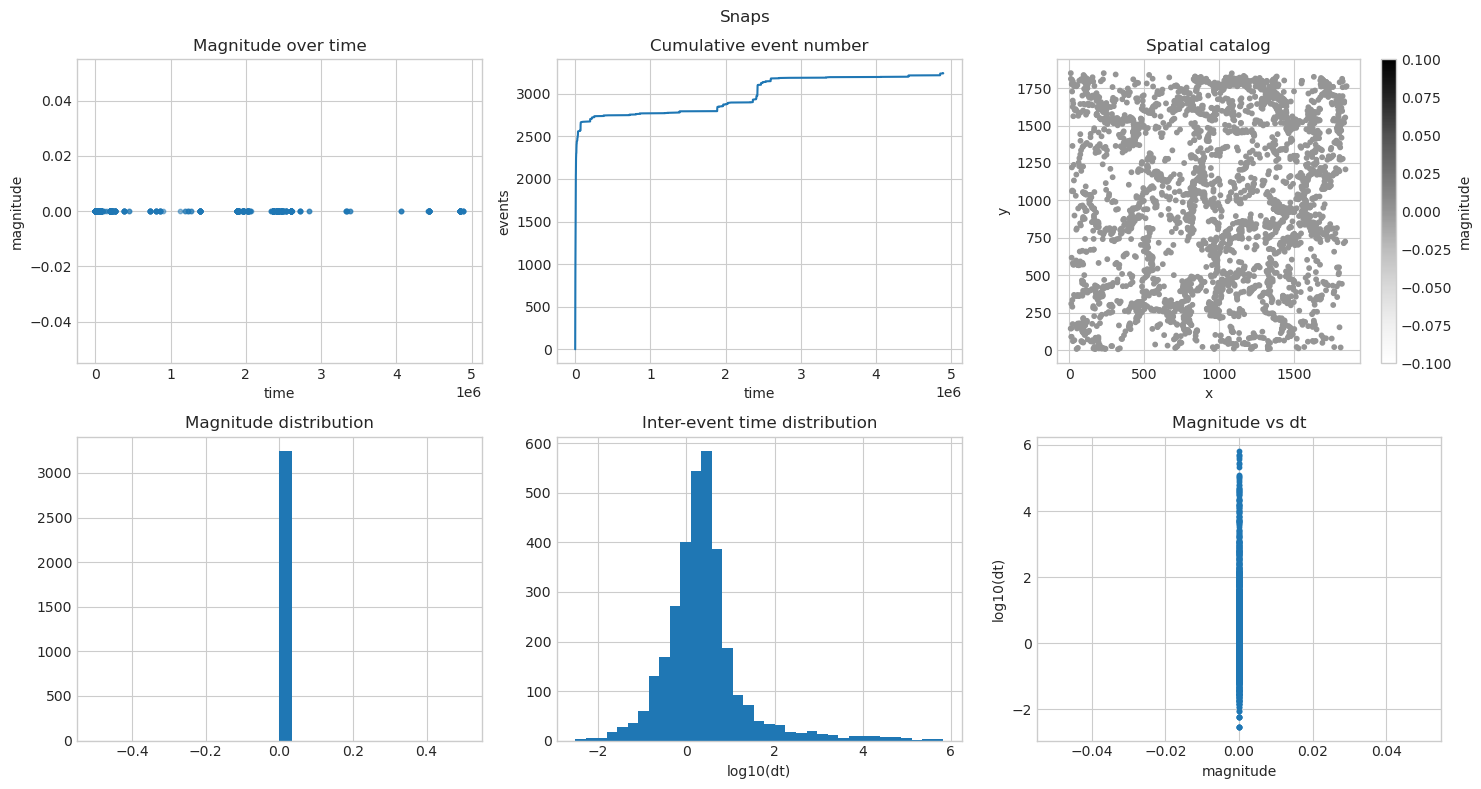

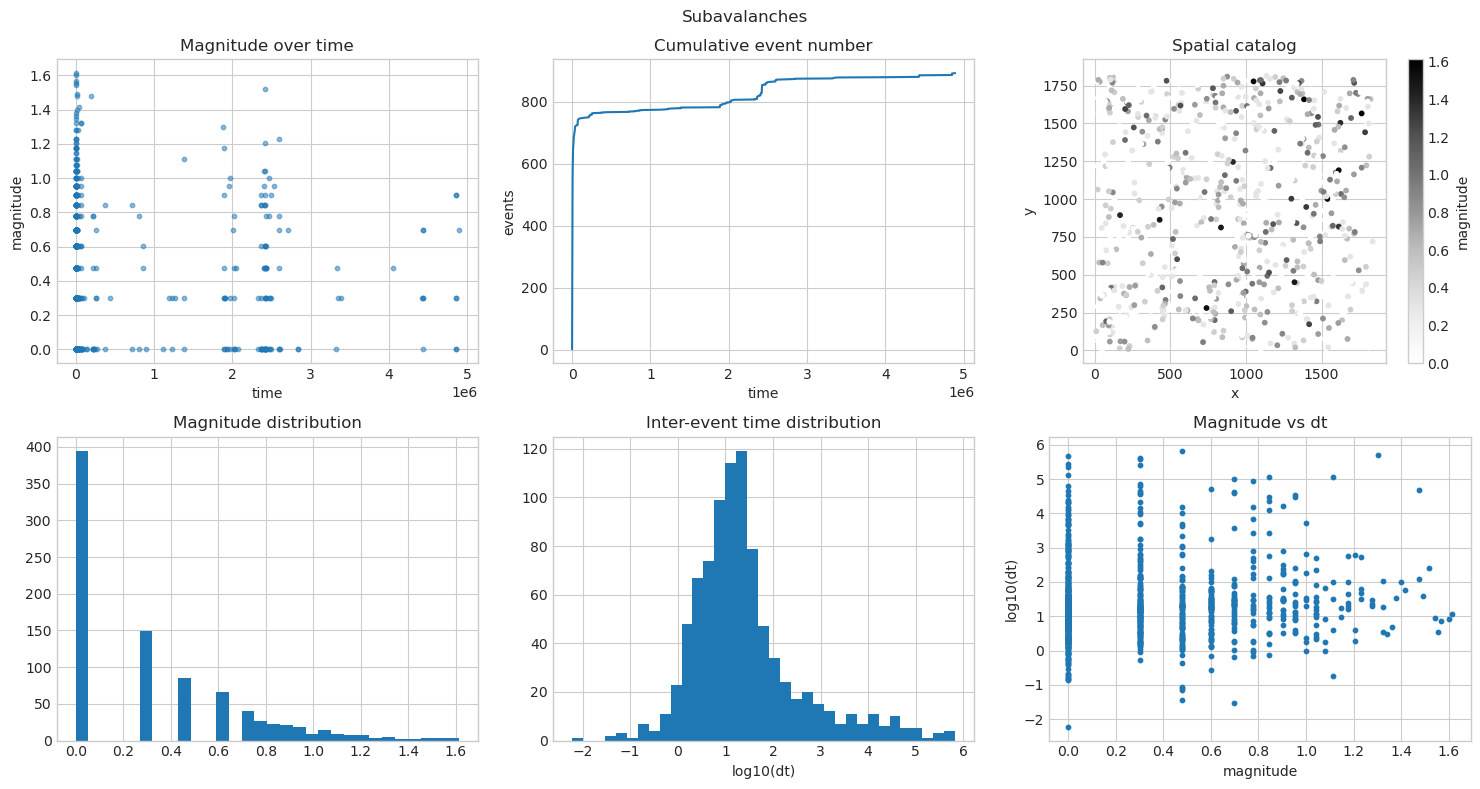

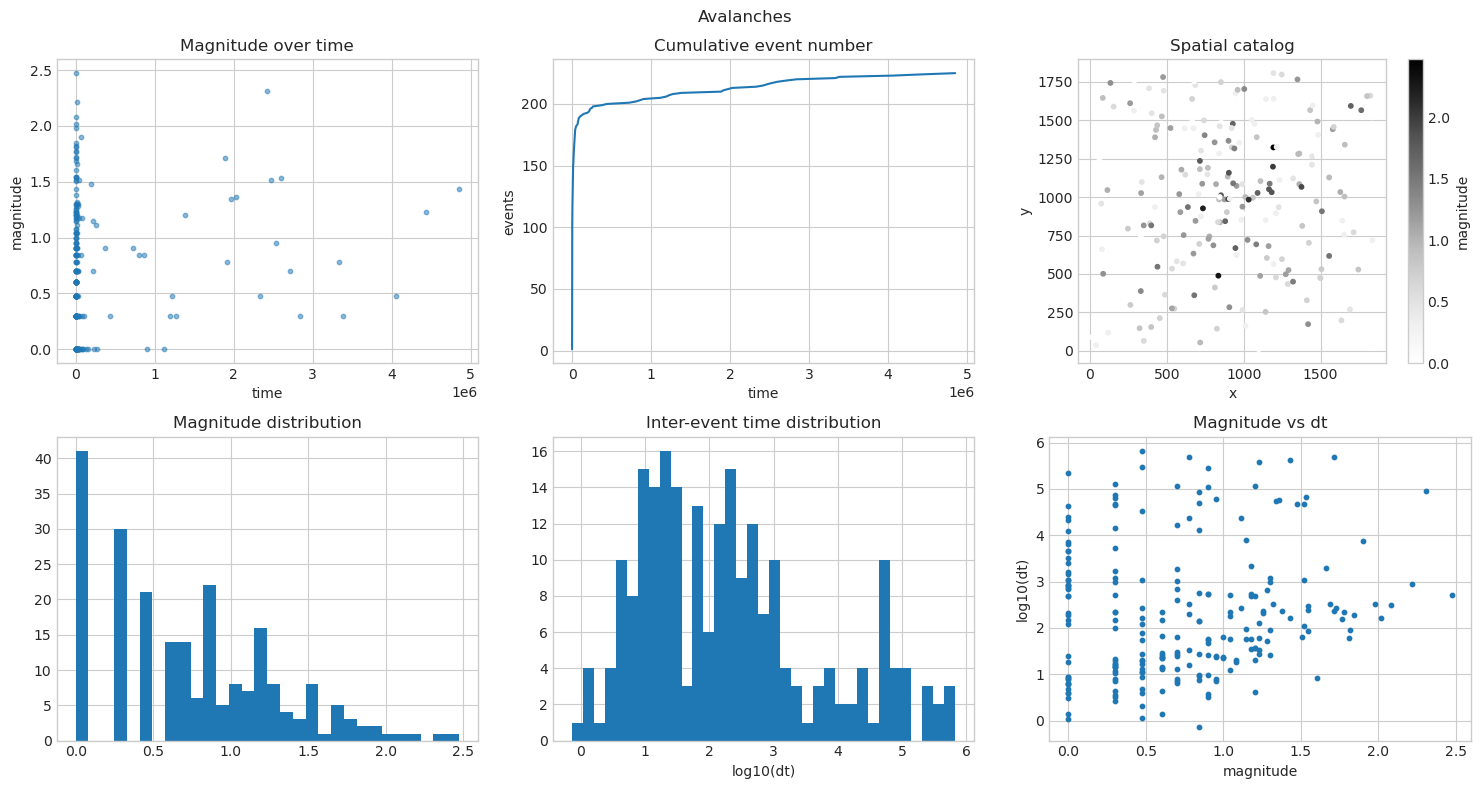

In [3]:
def plot_catalog(frame: pd.DataFrame, title: str) -> None:
    positive_dt = frame.loc[frame["dt"] > 0]
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(title)
    axes[0, 0].scatter(frame["time"], frame["magnitude"], s=10, alpha=0.5)
    axes[0, 0].set(xlabel="time", ylabel="magnitude", title="Magnitude over time")
    axes[0, 1].plot(frame["time"], frame["cumulative_count"])
    axes[0, 1].set(xlabel="time", ylabel="events", title="Cumulative event number")
    spatial = axes[0, 2].scatter(frame["x"], frame["y"], c=frame["magnitude"], s=10)
    axes[0, 2].set(xlabel="x", ylabel="y", title="Spatial catalog")
    axes[0, 2].set_aspect("equal", adjustable="box")
    fig.colorbar(spatial, ax=axes[0, 2], label="magnitude")
    axes[1, 0].hist(frame["magnitude"], bins=30)
    axes[1, 0].set(title="Magnitude distribution")
    axes[1, 1].hist(positive_dt["log10_dt"], bins=35)
    axes[1, 1].set(xlabel="log10(dt)", title="Inter-event time distribution")
    axes[1, 2].scatter(positive_dt["magnitude"], positive_dt["log10_dt"], s=10)
    axes[1, 2].set(xlabel="magnitude", ylabel="log10(dt)", title="Magnitude vs dt")
    fig.tight_layout()


for frame, title in ((snaps, "Snaps"), (subav, "Subavalanches"), (av, "Avalanches")):
    plot_catalog(frame, title)
plt.show()


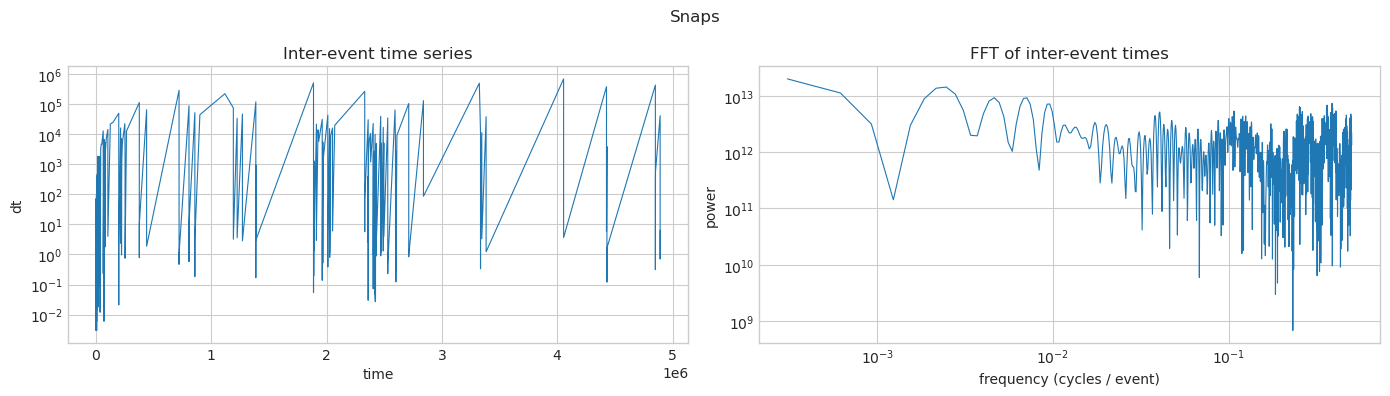

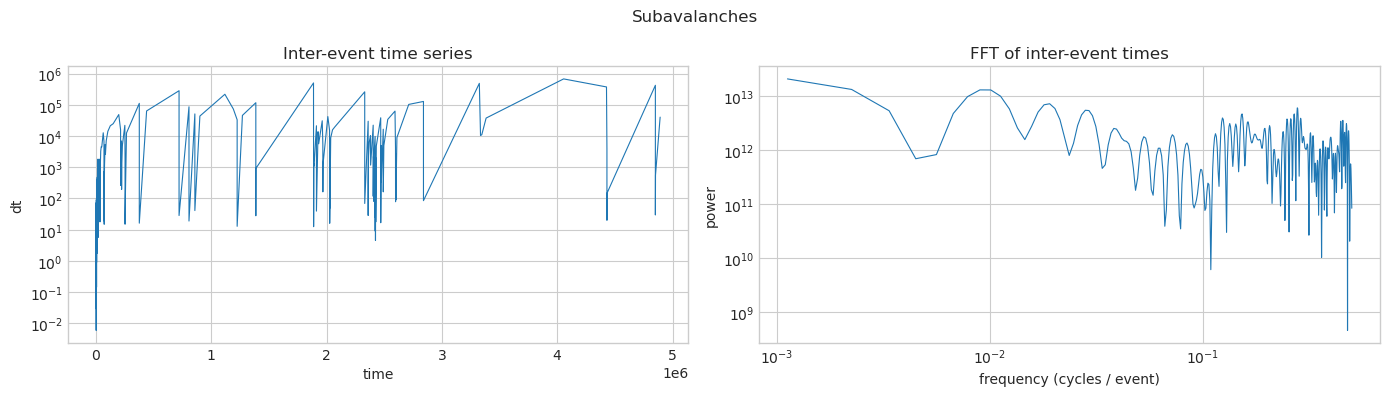

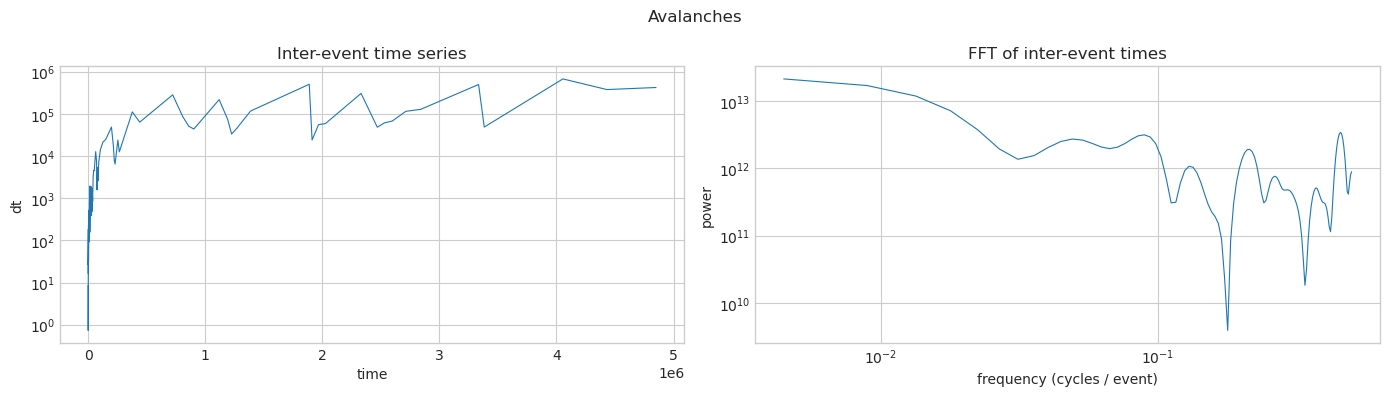

In [4]:
def plot_inter_event_fft(frame: pd.DataFrame, title: str) -> None:
    series = frame.loc[frame["dt"] > 0, ["time", "dt"]].dropna()
    dt = series["dt"].to_numpy(dtype=float)
    time = series["time"].to_numpy(dtype=float)

    detrended = dt - dt.mean()
    spectrum = np.fft.rfft(detrended)
    freqs = np.fft.rfftfreq(len(dt), d=1.0)
    power = np.abs(spectrum) ** 2

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(title)

    axes[0].plot(time, dt, lw=0.8)
    axes[0].set(xlabel="time", ylabel="dt", title="Inter-event time series")
    axes[0].set_yscale("log")

    axes[1].plot(freqs[1:], power[1:], lw=0.8)
    axes[1].set(
        xlabel="frequency (cycles / event)",
        ylabel="power",
        title="FFT of inter-event times",
        yscale="log",
        xscale="log",
    )
    fig.tight_layout()


for frame, title in ((snaps, "Snaps"), (subav, "Subavalanches"), (av, "Avalanches")):
    plot_inter_event_fft(frame, title)
plt.show()


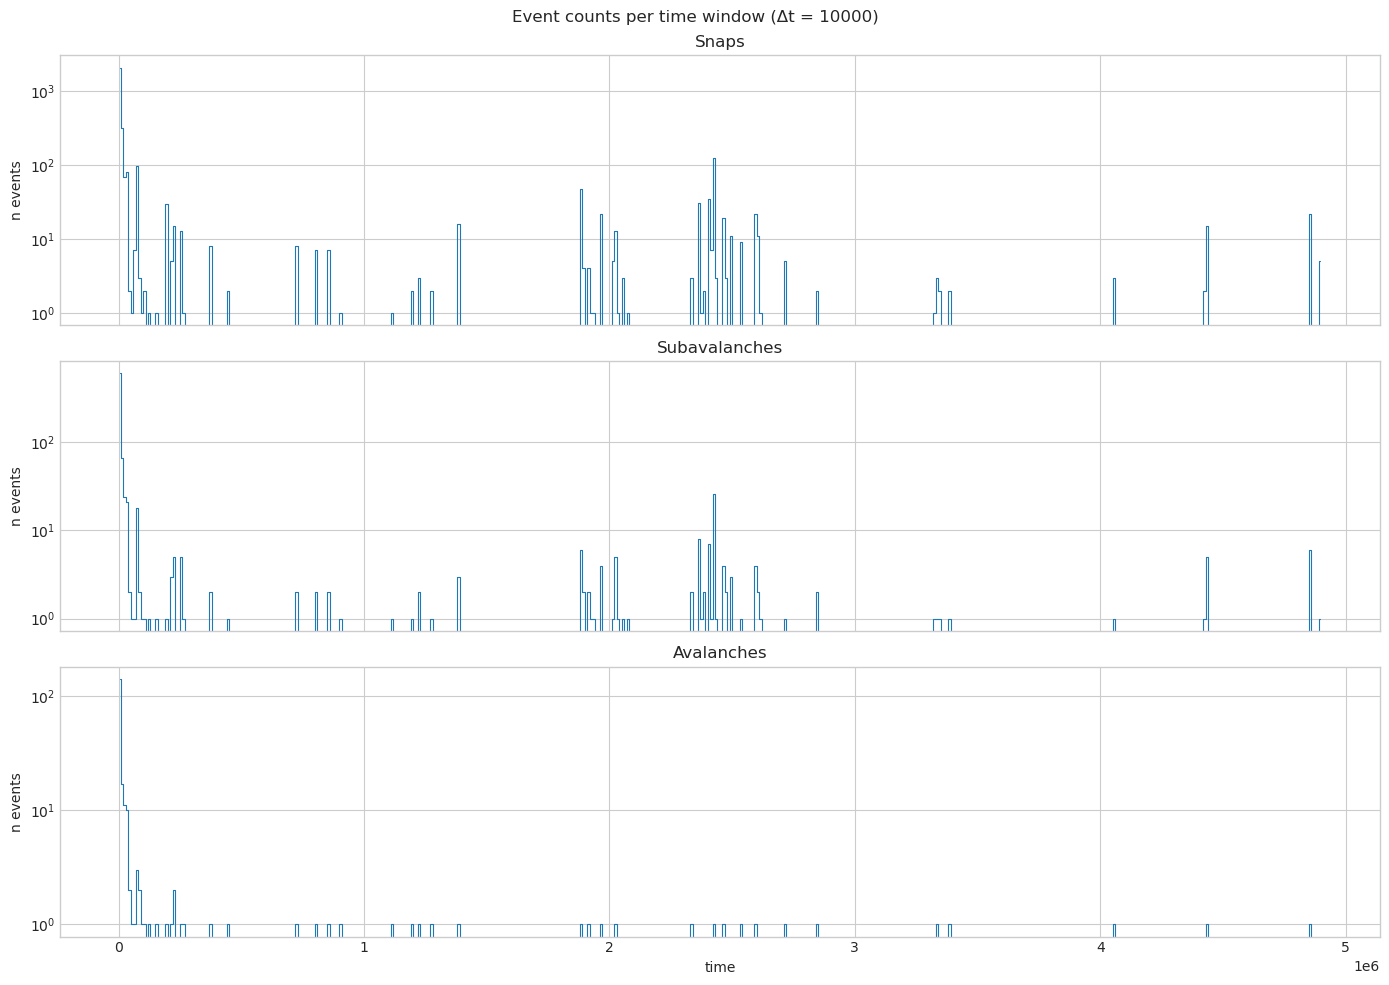

In [8]:
window = 1e4  # time-window width for event counts

t_min = min(frame["time"].min() for frame in (snaps, subav, av))
t_max = max(frame["time"].max() for frame in (snaps, subav, av))
edges = np.arange(t_min, t_max + window, window)
centers = 0.5 * (edges[:-1] + edges[1:])

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle(f"Event counts per time window (Δt = {window:g})")

for ax, (frame, title) in zip(
    axes, ((snaps, "Snaps"), (subav, "Subavalanches"), (av, "Avalanches"))
):
    counts, _ = np.histogram(frame["time"], bins=edges)
    ax.plot(centers, counts, lw=0.8, drawstyle="steps-mid")
    ax.set(ylabel="n events", title=title, yscale="log")

axes[-1].set_xlabel("time")
fig.tight_layout()
plt.show()



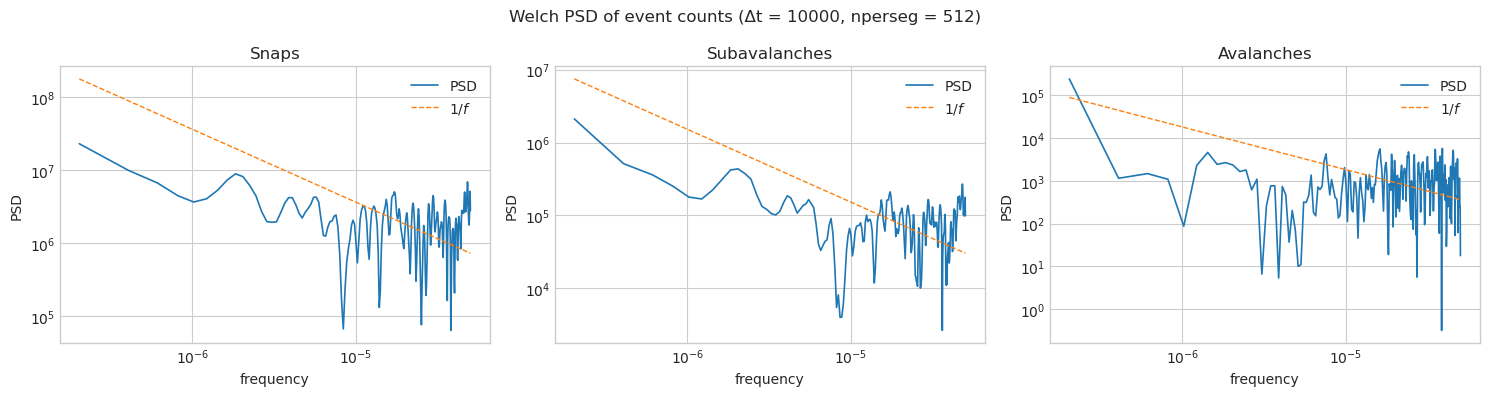

In [11]:
# Welch PSD of the binned event-count time series (same Δt as the rate plot above).
nperseg = 512
fs = 1.0 / window  # samples per unit simulation time

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
fig.suptitle(f"Welch PSD of event counts (Δt = {window:g}, nperseg = {nperseg})")

for ax, (frame, title) in zip(
    axes, ((snaps, "Snaps"), (subav, "Subavalanches"), (av, "Avalanches"))
):
    counts, _ = np.histogram(frame["time"], bins=edges)
    series = counts.astype(float) - counts.mean()

    seg = min(nperseg, len(series) // 2 * 2)  # even length, fit the series
    if seg < 8:
        ax.set(title=f"{title}: too few bins for Welch")
        continue

    freqs, psd = signal.welch(
        series,
        fs=fs,
        window="hann",
        nperseg=seg,
        scaling="density",
    )

    positive = freqs > 0
    f = freqs[positive]
    p = psd[positive]
    ax.loglog(f, p, lw=1.2, label="PSD")

    # 1/f reference scaled to mid-band power.
    i0, i1 = len(f) // 4, max(len(f) // 2, len(f) // 4 + 1)
    scale = float(np.median(p[i0:i1] * f[i0:i1]))
    ax.loglog(f, scale / f, ls="--", lw=1.0, label=r"$1/f$")

    ax.set(xlabel="frequency", ylabel="PSD", title=title)
    ax.legend(frameon=False)

fig.tight_layout()
plt.show()


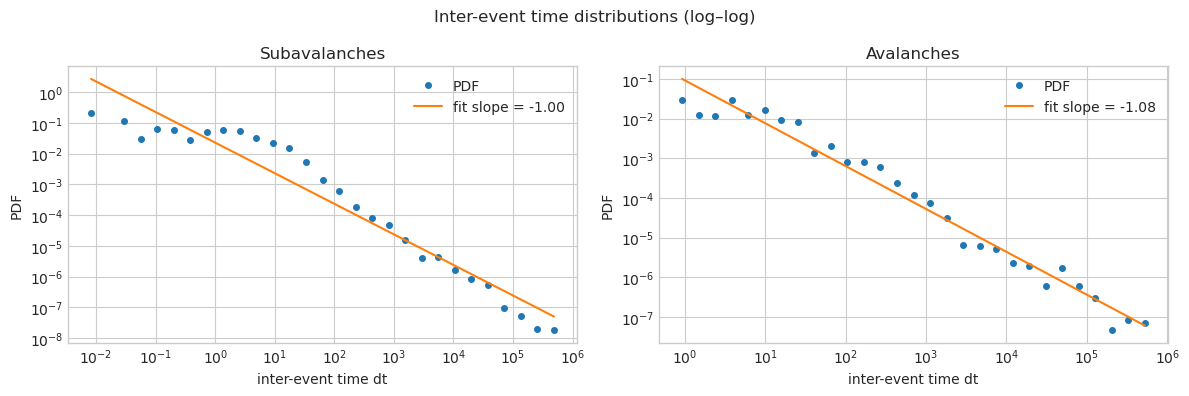

Subavalanche waiting-time slope: -0.995
Avalanche waiting-time slope: -1.081


In [12]:
def plot_waiting_time_powerlaw(frame: pd.DataFrame, title: str, ax) -> float:
    dt = frame.loc[frame["dt"] > 0, "dt"].to_numpy(dtype=float)
    bins = np.logspace(np.log10(dt.min()), np.log10(dt.max()), 30)
    counts, edges = np.histogram(dt, bins=bins)
    widths = np.diff(edges)
    centers = np.sqrt(edges[:-1] * edges[1:])  # geometric bin centers
    pdf = counts / (len(dt) * widths)

    positive = (counts > 0) & (pdf > 0)
    x = centers[positive]
    y = pdf[positive]

    ax.loglog(x, y, "o", ms=4, label="PDF")

    log_x = np.log10(x)
    log_y = np.log10(y)
    slope, intercept = np.polyfit(log_x, log_y, 1)
    x_fit = np.logspace(log_x.min(), log_x.max(), 100)
    y_fit = 10 ** (slope * np.log10(x_fit) + intercept)
    ax.loglog(x_fit, y_fit, "-", lw=1.5, label=f"fit slope = {slope:.2f}")

    ax.set(xlabel="inter-event time dt", ylabel="PDF", title=title)
    ax.legend(frameon=False)
    return float(slope)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Inter-event time distributions (log–log)")

slope_sub = plot_waiting_time_powerlaw(subav, "Subavalanches", axes[0])
slope_av = plot_waiting_time_powerlaw(av, "Avalanches", axes[1])

fig.tight_layout()
plt.show()
print(f"Subavalanche waiting-time slope: {slope_sub:.3f}")
print(f"Avalanche waiting-time slope: {slope_av:.3f}")
